In [1]:
from langgraph.graph import StateGraph, START, END
from typing import Literal, TypedDict, Annotated
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
import os

In [ ]:
load_dotenv()

True

In [6]:
api_token = os.getenv("HUGGINGFACE_API_KEY")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="conversational",
    max_new_tokens=100,
    temperature=0.1,
    huggingfacehub_api_token=api_token,
)

chat_model = ChatHuggingFace(llm=llm)

In [7]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [ ]:
def step_1(state: CrashState) -> CrashState:
    print("step1 executed")

    return {'step1': 'done', 'input': state['input']}

In [10]:
import time
def step_2(state: CrashState) -> CrashState:
    print("step2 hanging.... now manually interuput from notebook toolar(stop button)")
    time.sleep(30)
    return {'step2': 'done'}

In [16]:
def step_3(state: CrashState) -> CrashState:
    print("step3 executed")
    return {'step3': 'done'}

In [17]:
builder = StateGraph(CrashState)

builder.add_node('step1', step_1)
builder.add_node('step2', step_2)
builder.add_node('step3', step_3)

builder.add_edge(START, 'step1')
builder.add_edge('step1', 'step2')
builder.add_edge('step2', 'step3')
builder.add_edge('step3', END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

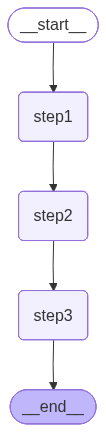

In [18]:
graph

In [19]:
try:
    print("Running graph: manually interuupt during step2")
    graph.invoke({'input': 'start'}, config = {'configurable': {'thread_id': 'crash_test_thread'}})
except KeyboardInterrupt:
    print("kernel manually interrupted")

Running graph: manually interuupt during step2
step2 hanging.... now manually interuput from notebook toolar(stop button)
kernel manually interrupted


In [20]:
graph.get_state({'configurable': {'thread_id': 'crash_test_thread'}})

StateSnapshot(values={'input': 'start'}, next=('step1',), config={'configurable': {'thread_id': 'crash_test_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f167b84-7be3-633f-8000-a164ea0001f2'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-14T06:14:20.048604+00:00', parent_config={'configurable': {'thread_id': 'crash_test_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f167b84-7bcf-613c-bfff-a6d2f06cfcb5'}}, tasks=(PregelTask(id='7669bce9-85eb-8538-09c2-0929a2ac00f3', name='step1', path=('__pregel_pull', 'step1'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [21]:
list(graph.get_state_history({'configurable': {'thread_id': 'crash_test_thread'}}))

[StateSnapshot(values={'input': 'start'}, next=('step1',), config={'configurable': {'thread_id': 'crash_test_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f167b84-7be3-633f-8000-a164ea0001f2'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-14T06:14:20.048604+00:00', parent_config={'configurable': {'thread_id': 'crash_test_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f167b84-7bcf-613c-bfff-a6d2f06cfcb5'}}, tasks=(PregelTask(id='7669bce9-85eb-8538-09c2-0929a2ac00f3', name='step1', path=('__pregel_pull', 'step1'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': 'crash_test_thread', 'checkpoint_ns': '', 'checkpoint_id': '1f167b84-7bcf-613c-bfff-a6d2f06cfcb5'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-06-14T06:14:20.040346+00:00', parent_config=None, tasks=(PregelTask(id='f786dedf-cadc-fec1-3394-2cc28c145cee', name

In [22]:
final_state = graph.invoke(None, config = {'configurable': {'thread_id': 'crash_test_thread', 'resume_from': 'step2'}})

step2 hanging.... now manually interuput from notebook toolar(stop button)
step2 hanging.... now manually interuput from notebook toolar(stop button)
step3 executed


In [ ]:
graph.get_state({'configurable': {'thread_id': 'crash_test_thread'}})